# import packages

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import datetime

# prepare data: batch_size, download dataset, trainloader, testloader

In [2]:
batch_size=32

In [3]:
transform = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5,0.5,0.5), (0.5, 0.5, 0.5))])

In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=transform)


Files already downloaded and verified


In [5]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

In [6]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=False, transform=transform)


In [7]:
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)


# define names of  classes, show some images

In [8]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

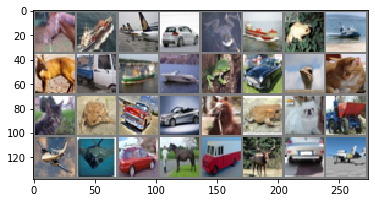

horse  ship plane   car  frog  ship  frog plane  deer truck  ship  ship  frog   car  bird   cat   cat  frog   car   car horse  frog   dog truck plane plane   car horse truck  deer   car plane


In [9]:
def imshow(img):
    img = img / 2 +0.5  # unnormalize
    plt.imshow(img.permute(1,2,0))
    plt.show()

# get some random training images
dataiter= iter(trainloader) # return an iterator assigned to dataiter
images, labels = dataiter.next() # get the current iteration on dataiter: [batch_size, C, H, W]

# show images in one batch
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join ('%5s' % classes[labels[j]] for j in range(batch_size)))

In [10]:
trainloader

# define CNN architecture

In [11]:
import torch.nn as nn
import torch.nn.functional as F

In [14]:
class Net(nn.Module):
    def __init__(self):   # define self functions for all layers with learning parameters
        super(Net, self).__init__()   
        self.conv1 = nn.Conv2d(3,6,5)  # define function sefl.conv1 for Conv layer1
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6,16,5)
        #self.bn1 = nn.BatchNorm2d(6) # batch normalization
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120,84)
        self.bn2 = nn.BatchNorm1d(84) # batch normalization
        self.fc3 = nn.Linear(84,10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x,2,2)
        x = self.bn1(x) # batch normalization
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x,2,2)
        x = x.view(-1, 16*5*5)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.bn2(x) # batch normalization
        x = self.fc3(x)
        return x
net = Net()

#  train the model

In [13]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [14]:
for epoch in range(5):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader,0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        
        if i % 100 == 99:    # print every 100 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 100))
            running_loss = 0.0
        
print('Finished Training')

[1,   100] loss: 1.898
[1,   200] loss: 1.657
[1,   300] loss: 1.584
[1,   400] loss: 1.502
[1,   500] loss: 1.470
[1,   600] loss: 1.459
[1,   700] loss: 1.427
[1,   800] loss: 1.375
[1,   900] loss: 1.391
[1,  1000] loss: 1.331
[1,  1100] loss: 1.346
[1,  1200] loss: 1.336
[1,  1300] loss: 1.356
[1,  1400] loss: 1.321
[1,  1500] loss: 1.319
[2,   100] loss: 1.223
[2,   200] loss: 1.204
[2,   300] loss: 1.223
[2,   400] loss: 1.201
[2,   500] loss: 1.212
[2,   600] loss: 1.273
[2,   700] loss: 1.188
[2,   800] loss: 1.229
[2,   900] loss: 1.215
[2,  1000] loss: 1.153
[2,  1100] loss: 1.220
[2,  1200] loss: 1.225
[2,  1300] loss: 1.215
[2,  1400] loss: 1.199
[2,  1500] loss: 1.187
[3,   100] loss: 1.071
[3,   200] loss: 1.141
[3,   300] loss: 1.104
[3,   400] loss: 1.126
[3,   500] loss: 1.096
[3,   600] loss: 1.110
[3,   700] loss: 1.112
[3,   800] loss: 1.125
[3,   900] loss: 1.122
[3,  1000] loss: 1.109
[3,  1100] loss: 1.111
[3,  1200] loss: 1.103
[3,  1300] loss: 1.092
[3,  1400] 

# test the model

In [15]:
len(trainset)

50000

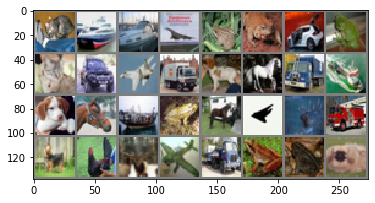

GroundTruth:    cat  ship  ship plane  frog  frog   car  frog   cat   car plane truck   dog horse truck  ship   dog horse  ship  frog horse plane  deer truck   dog  bird  deer plane truck  frog  frog   dog


In [16]:
dataiter = iter(testloader)
images, labels = dataiter.next()

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(batch_size)))

In [17]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

In [18]:
outputs = net(images)

In [19]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(batch_size)))

Predicted:    cat  ship truck plane  deer  frog   car  frog  deer   car  deer truck   dog horse truck  ship   dog  frog  ship  frog horse plane  deer truck  deer  bird  deer plane truck  frog  frog   dog


In [20]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 63 %


In [21]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 68 %
Accuracy of   car : 72 %
Accuracy of  bird : 47 %
Accuracy of   cat : 34 %
Accuracy of  deer : 63 %
Accuracy of   dog : 52 %
Accuracy of  frog : 79 %
Accuracy of horse : 68 %
Accuracy of  ship : 71 %
Accuracy of truck : 76 %


In [22]:
predicted

tensor([6, 9, 0, 0, 8, 4, 7, 0, 3, 3, 3, 5, 6, 5, 0, 7])

In [23]:
inputs.size()

torch.Size([16, 3, 32, 32])

In [24]:
outputs.size()

torch.Size([16, 10])

In [25]:
images.size()

torch.Size([16, 3, 32, 32])

In [26]:
outputs

tensor([[-1.0180, -2.2763,  1.4399,  1.2907,  1.4813,  0.2056,  1.5145,  1.3269,
         -2.0115, -3.0396],
        [-2.2311, -0.1922, -0.4016,  2.9500, -2.9843,  1.7959, -1.6588,  0.2913,
         -3.1531,  3.5670],
        [ 3.0860, -0.2036,  1.1732, -1.4415,  0.8107, -1.5532, -2.4276, -1.6762,
          2.6903,  0.4695],
        [ 5.3463,  2.7024, -0.7551, -1.9051,  1.6510, -2.4712, -4.8002, -2.3197,
          2.8945,  1.0283],
        [ 3.3933,  3.8463, -0.2292, -3.1648, -2.7919, -4.2433, -0.8703, -4.3613,
          4.8388,  4.6201],
        [-1.8235, -3.0971,  2.7821,  0.0069,  5.2907, -0.1164,  0.0827, -0.4828,
         -0.8533, -4.0304],
        [-1.1806, -2.2933,  1.3887,  0.8853, -0.9741,  1.2158, -1.6141,  3.3734,
         -2.2950, -0.0539],
        [ 6.0685,  1.0416, -1.8123, -2.9420, -1.1922, -3.1811, -6.1998,  1.0252,
          0.7418,  5.0572],
        [-1.2220, -1.5608, -1.1827,  2.7560,  0.2652,  2.1495,  2.7051, -0.4593,
         -1.6230, -2.1947],
        [-1.3460, -

In [27]:
predicted

tensor([6, 9, 0, 0, 8, 4, 7, 0, 3, 3, 3, 5, 6, 5, 0, 7])

In [28]:
predicted.size()

torch.Size([16])

In [15]:
numel_list = [p.numel() for p in net.parameters()]
sum(numel_list), numel_list


(62186, [450, 6, 6, 6, 2400, 16, 48000, 120, 10080, 84, 84, 84, 840, 10])

# the follow codes is to dispaly MNIST examples

In [18]:
batch_size = 128
mnist_trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                       download=True, transform=transforms.ToTensor())
Mnist = torch.utils.data.DataLoader(mnist_trainset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

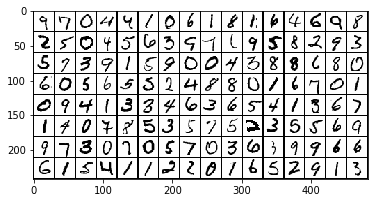

In [19]:
def imshow_grey(img):
    plt.imshow(img.permute(1,2,0),cmap="Greys")
    plt.show()

# get some random training images
dataiter= iter(Mnist) # return an iterator assigned to dataiter
images, labels = dataiter.next() # get the current iteration on dataiter: [batch_size, C, H, W]

# show images in one batch, "255-images" reverses the black and white for a white background 
imshow_grey(torchvision.utils.make_grid(255-images, nrow=16, normalize=True))



In [14]:
images.shape

torch.Size([128, 1, 28, 28])

In [25]:
numel_list = [p.numel() for p in net.parameters()]
sum(numel_list), numel_list


(62006, [450, 6, 2400, 16, 48000, 120, 10080, 84, 840, 10])